### Part B

Next, we fit a linear regression model to the data.

## Problem 1


### Part A
The following code generates 50 samples with a single input feature, where the target variable has some noise. The random seed ensures consistency between runs.

In [ ]:
import numpy as np
from sklearn.datasets import make_regression

X, y = make_regression(
    n_samples=50,
    n_features=1,
    noise=10,
    random_state=42
)


In [3]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

### Part C

Plot predicted versus actuals

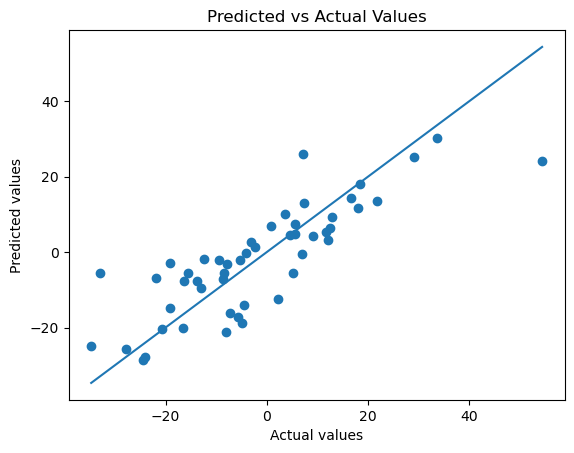

In [4]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Predicted vs Actual Values")
plt.show()

From the plot, we see a linear correlation. Playing with the `noise` parameter in the call to `make_regression` would result in a stronger correlation (smaller noise value) or a weaker correlation (larger noise value).

### Part D

In [5]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y, y_pred)
print(f"Mean Squared Error (MSE): {mse:.3f}")

Mean Squared Error (MSE): 93.490


The MSE for this data set is 93.49. 

Since we set `noise = 10` when generating the data, the expected MSE is $10^2=100.$ We're close to that, so the model is performing well.

## Problem 2

### Part A

In [6]:
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()


X = iris.data
y = iris.target

print(iris.feature_names)
print(X.shape)

print(np.unique(y))

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
(150, 4)
[0 1 2]


From the output `(150,4)` we see X has 4 columns representing the 4 features from the dataset. We also see y has three unique classes `[0 1 2]`.

### Part B

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print(X_pca.shape)

(150, 2)


The output `(150,2)` confirms the dimensions are reduced to two features.

### Part C

We perform the KMeans clustering using 3 clusters. The `random_state` parameter ensures reproducibility for future runs. 

The `n_init` parameter is set to surpress a warning about its default value changing from `10` to `auto` in a future version.

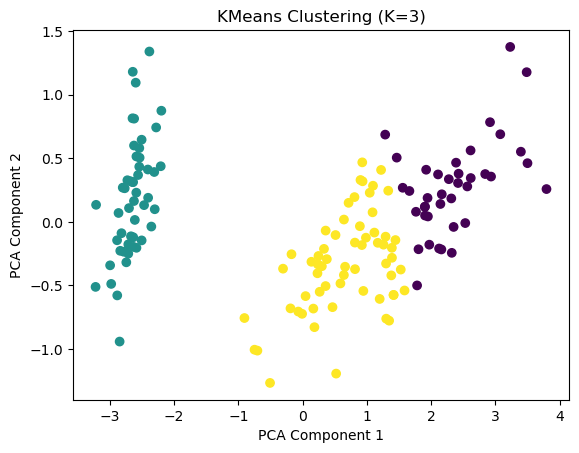

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

# Scatter plot
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("KMeans Clustering (K=3)")
plt.show()

We see three clearly separated clusters. The left most cluster is completely isolated along the first principal component, the other two are mostly separated with slight overlap. This indicates a three-cluster structure in the Iris dataset that is captured well by PCA and KMeans.

## Problem 3

### Part A

Load the reviews.

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 72
from IPython.display import display
import numpy as np
from scipy.sparse import lil_matrix
import pandas as pd

MOVIE_DATA_CSV= '../../datasets/movie_data.csv'

In [10]:
df = pd.DataFrame()
df = pd.read_csv(MOVIE_DATA_CSV)    

# Sanity
print(f'#rows={len(df)} #columns={len(df.columns)}')
df.head()

#rows=50000 #columns=2


,review,sentiment
0,"In 1974, the teenager Martha Moxley (Maggie Gr...",1
1,OK... so... I really like Kris Kristofferson a...,0
2,"***SPOILER*** Do not read this, if you think a...",0
3,hi for all the people who have seen this wonde...,1
4,"I recently bought the DVD, forgetting just how...",0


In [11]:
Reviews = [_ for _ in df.review if _ != 'Unknown']

# sanity
print(len(Reviews))
print(Reviews[0:3])

50000
['In 1974, the teenager Martha Moxley (Maggie Grace) moves to the high-class area of Belle Haven, Greenwich, Connecticut. On the Mischief Night, eve of Halloween, she was murdered in the backyard of her house and her murder remained unsolved. Twenty-two years later, the writer Mark Fuhrman (Christopher Meloni), who is a former LA detective that has fallen in disgrace for perjury in O.J. Simpson trial and moved to Idaho, decides to investigate the case with his partner Stephen Weeks (Andrew Mitchell) with the purpose of writing a book. The locals squirm and do not welcome them, but with the support of the retired detective Steve Carroll (Robert Forster) that was in charge of the investigation in the 70\'s, they discover the criminal and a net of power and money to cover the murder.<br /><br />"Murder in Greenwich" is a good TV movie, with the true story of a murder of a fifteen years old girl that was committed by a wealthy teenager whose mother was a Kennedy. The powerful and ric

Tokenize the reviews, removing html and stop words.

In [12]:
# These are needed for stopwords
from nltk import regexp_tokenize
from nltk.corpus import stopwords
import nltk

import re

HTML_TAGS = [
    r'<\s*br\s*/?\s*>',
    r'<\s*/?\s*i\s*>',
    r'<\s*/?\s*em\s*>',
]

def strip_known_html(text):
    for pat in HTML_TAGS:
        text = re.sub(pat, ' ', text, flags=re.IGNORECASE)
    return text

# from the sklearn API the default token_pattern='(?u)\\b\\w\\w+\\b'
TOKEN_PATTERN= r'(?u)\b[a-zA-Z]\w+\b'

nltk.download("punkt")
nltk.download("punkt_tab")

nltk.download('stopwords')

STOP_WORDS = set(stopwords.words('english'))

reviews_tok = []

def clean_and_tokenize_review(review: str) -> list[str]:
    text = strip_known_html(review)
    tokens = regexp_tokenize(text.lower(), TOKEN_PATTERN)  
    tokens = [t for t in tokens if t not in STOP_WORDS]
    return tokens

for review in Reviews:
    toks = clean_and_tokenize_review(review)
    if len(toks) == 0:
        continue  # skip empty reviews after filtering
    reviews_tok.append(toks)


print(len(reviews_tok))
print(reviews_tok[0:3])

[nltk_data] Downloading package punkt to /Users/jeff/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/jeff/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/jeff/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


50000
[['teenager', 'martha', 'moxley', 'maggie', 'grace', 'moves', 'high', 'class', 'area', 'belle', 'greenwich', 'connecticut', 'mischief', 'night', 'eve', 'halloween', 'murdered', 'backyard', 'house', 'murder', 'remained', 'unsolved', 'twenty', 'two', 'years', 'later', 'writer', 'mark', 'fuhrman', 'christopher', 'meloni', 'former', 'la', 'detective', 'fallen', 'disgrace', 'perjury', 'simpson', 'trial', 'moved', 'idaho', 'decides', 'investigate', 'case', 'partner', 'stephen', 'weeks', 'andrew', 'mitchell', 'purpose', 'writing', 'book', 'locals', 'squirm', 'welcome', 'support', 'retired', 'detective', 'steve', 'carroll', 'robert', 'forster', 'charge', 'investigation', 'discover', 'criminal', 'net', 'power', 'money', 'cover', 'murder', 'murder', 'greenwich', 'good', 'tv', 'movie', 'true', 'story', 'murder', 'fifteen', 'years', 'old', 'girl', 'committed', 'wealthy', 'teenager', 'whose', 'mother', 'kennedy', 'powerful', 'rich', 'family', 'used', 'influence', 'cover', 'murder', 'twenty', 

Generate TF-IDF features.

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

def tokenizer_i(_x):
    return _x
vec = TfidfVectorizer(tokenizer=tokenizer_i, token_pattern=None,
lowercase=False, stop_words=None, max_features=1000, dtype=np.float32)
X = vec.fit_transform(reviews_tok).toarray()

print(X.shape)
print(X[0:3])

(50000, 1000)
[[0.10896096 0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.08137626 0.         0.        ]]


We've created a matrix X with one row for each of the 50K reviews. The columns represent the top 1000 words based on normalized frequencies. Since we removed stop words when we did our initial tokenization above they will not appear. 

Each entry in X is the TF-IDF value for the word (column) in the review (row). Many entries will be 0 because many words from the entire set will not appear in a given review. A non-zero value will be high for a word the appears frequently in the given review, but infrequently across the other reviews. 

The value is the term frequency (TF) which is how often the word appears in the review multiplied by the Inverse Document Frequency (IDF) which is a measure of how rare a term is across the corpus. Higher IDF corresponds to higher rarity. 

### Part B


In [14]:
print(len(vec.vocabulary_))
print(list(vec.vocabulary_.items())[:100])

1000
[('moves', 565), ('high', 403), ('class', 140), ('night', 589), ('house', 417), ('murder', 571), ('two', 909), ('years', 993), ('later', 474), ('writer', 985), ('mark', 526), ('former', 340), ('la', 466), ('decides', 198), ('case', 117), ('writing', 987), ('book', 89), ('robert', 719), ('power', 666), ('money', 560), ('cover', 172), ('good', 375), ('tv', 907), ('movie', 566), ('true', 899), ('story', 830), ('old', 605), ('girl', 363), ('whose', 963), ('mother', 563), ('powerful', 667), ('rich', 715), ('family', 292), ('used', 921), ('however', 418), ('able', 0), ('crime', 181), ('screenplay', 745), ('shows', 778), ('last', 472), ('days', 191), ('lack', 467), ('title', 883), ('ok', 603), ('really', 696), ('like', 493), ('usual', 924), ('easy', 236), ('going', 373), ('lines', 496), ('movies', 567), ('age', 15), ('low', 514), ('style', 839), ('scene', 737), ('bad', 61), ('must', 574), ('give', 366), ('cinematography', 138), ('actors', 8), ('including', 429), ('trying', 903), ('make',

`vec.vocabulary_` holds the column index for each word in the TF-IDF matrix.

There are several ways we could look for "interesting" words. Just by scanning the output, the words `murder`, `robert`, and `cinematography` look interesting. 

We could also look at words with low and high IDF, to identify words that are common and rare across the corpus, respectively.

In [15]:
terms = vec.get_feature_names_out()
idf = vec.idf_

low_idf_idx = np.argsort(idf)[:10]
high_idf_idx = np.argsort(idf)[-10:][::-1]

print("Most frequent words (low IDF):")
for i in low_idf_idx:
    print(f"{terms[i]:10s}  idf={idf[i]:.3f}")

print("\nLeast frequent words (high IDF):")
for i in high_idf_idx:
    print(f"{terms[i]:10s}  idf={idf[i]:.3f}")

Most frequent words (low IDF):
movie       idf=1.492
one         idf=1.564
film        idf=1.588
like        idf=1.769
good        idf=1.967
time        idf=2.059
even        idf=2.096
see         idf=2.123
would       idf=2.128
really      idf=2.201

Least frequent words (high IDF):
jane        idf=5.521
zombie      idf=5.499
christmas   idf=5.433
alien       idf=5.416
match       idf=5.372
scott       idf=5.283
cat         idf=5.256
van         idf=5.253
train       idf=5.252
band        idf=5.249


The least frequent words, those with high IDF like `jane`, `zombie`, and `alien` seem more interesting than the frequent words with low IDF.

Finally, we could look for words with high TF-IDF. These words contribute strongly to a given review (high TF), but show up infrequently across the corpus (high IDF).

In [16]:
X_sparse = vec.transform(reviews_tok)
tf_idf = np.asarray(X_sparse.sum(axis=0)).ravel()

top_idx = np.argsort(tf_idf)[-10:][::-1]
bottom_idx = np.argsort(tf_idf)[:10]

print("Highest TF-IDF:")
for i in top_idx:
    print(f"{terms[i]:10s}  TF-IDF={tf_idf[i]:.3f}")

print("\nLowest TF-IDF:")
for i in bottom_idx:
    print(f"{terms[i]:10s}  TF-IDF={tf_idf[i]:.3f}")

Highest TF-IDF:
movie       TF-IDF=4031.312
film        TF-IDF=3548.806
one         TF-IDF=2353.811
like        TF-IDF=1976.286
good        TF-IDF=1725.956
story       TF-IDF=1464.596
time        TF-IDF=1460.429
would       TF-IDF=1452.071
really      TF-IDF=1445.453
see         TF-IDF=1428.628

Lowest TF-IDF:
sees        TF-IDF=115.842
suddenly    TF-IDF=119.119
ultimately  TF-IDF=122.343
decides     TF-IDF=122.378
successful  TF-IDF=123.141
focus       TF-IDF=124.117
longer      TF-IDF=124.592
alien       TF-IDF=125.317
amount      TF-IDF=125.874
match       TF-IDF=126.056


Other than `alien`, none of these are subjectively interesting to me :)

### Part C

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

print(len(X_std))

means = X_std.mean(axis=0)
print(means[:10])

stds = X_std.std(axis=0)
print(stds[:10])


50000
[-1.3545680e-06  1.2741220e-06 -6.4348399e-07 -6.9945571e-07
 -1.4715790e-06 -5.8616757e-07  8.0462218e-07 -1.1728406e-07
  1.1366611e-06  2.9691756e-07]
[0.9997469  1.0002681  1.0000324  0.99981064 1.0000428  0.999886
 0.99989855 0.99993974 1.0001895  1.0000591 ]


From the output, we see means very close to 0 and standard deviations very close to 1 which is what we expect after using `StandardScaler` to standardize the data. 

Standardizing in this way prevents the KMeans and PCA analysis we do below from being dominated by high-frequency terms.

### Part D

We perform the KMeans clustering using 2 clusters. The `random_state` parameter ensures reproducibility for future runs. 

The `n_init` parameter is set to suppress a warning about its default value changing from `10` to `auto` in a future version.

In [18]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_ids = kmeans.fit_predict(X_std)

print(len(cluster_ids))
print(cluster_ids[0:20])


50000
[1 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 1]


From the output, we see cluster IDs of 0 and 1 as expected for 2 clusters.

### Part E

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_std)

print(len(X_pca))
print(X_pca[0:5])

50000
[[ 3.3765588  -2.0430574 ]
 [-3.6554108   3.1894934 ]
 [-0.04062683  1.4854676 ]
 [-2.1177826  -4.129494  ]
 [ 0.76545024 -2.148226  ]]


The output shows we have projections on two components for all 50K reviews as expected.

### Part F

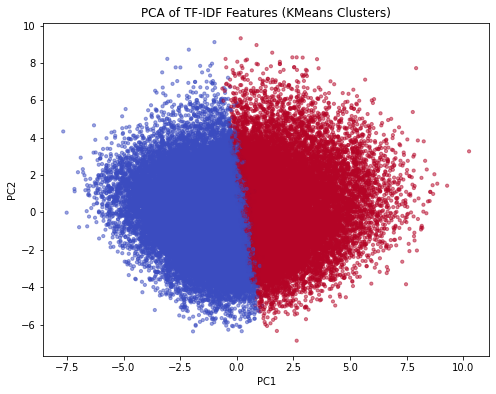

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_ids,
    cmap="coolwarm",
    alpha=0.5,
    s=10
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of TF-IDF Features (KMeans Clusters)")
plt.show()


Yes, there is good separation, we see two dense clusters with strong separation along the PC1 access, meaning PC1 meaningfully distinguishes clusters. There is overlap near the center for PC1. 

Along the vertical access, PC2 does not distinguish clusters.

### Part G

The code below finds the centroid, disregarding clusters. It then picks a point a that is far from the centroid and another point b that is far from point a. It then shows the corresponding reviews on the features plot.

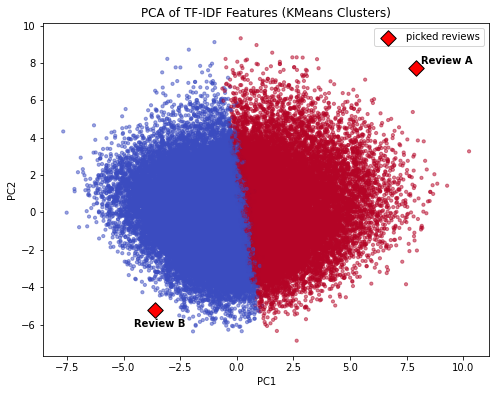

In [21]:
import numpy as np
import matplotlib.pyplot as plt

centroid = X_pca.mean(axis=0)

dist_to_centroid = np.linalg.norm(X_pca - centroid, axis=1)
idx_a = np.argmax(dist_to_centroid)

dist_from_a = np.linalg.norm(X_pca - X_pca[idx_a], axis=1)
idx_b = np.argmax(dist_from_a)

picked = [idx_a, idx_b]

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=cluster_ids, cmap="coolwarm", alpha=0.5, s=10)

plt.scatter(X_pca[picked, 0], X_pca[picked, 1],
            marker="D", s=120, c="red",
            edgecolors="black", linewidths=1.0,
            label="picked reviews")

offset = 0.2
plt.text(X_pca[idx_a, 0] + offset, X_pca[idx_a, 1] + offset,
         "Review A", fontsize=10, fontweight="bold")

offset = 0.9
plt.text(X_pca[idx_b, 0] - offset, X_pca[idx_b, 1] - offset,
         "Review B", fontsize=10, fontweight="bold")


plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of TF-IDF Features (KMeans Clusters)")
plt.legend()
plt.show()



Now we look at the reviews themselves. We'll look at the raw reviews rather than the tokenized reviews, so HTML tags and stop words will be included.

In [22]:
print("Review A text:\n", Reviews[idx_a][:5000])
print("\nReview B text:\n", Reviews[idx_b][:500])

Review A text:
 (Some spoilers included:)<br /><br />Although, many commentators have called this film surreal, the term fits poorly here. To quote from Encyclopedia Britannica's, surreal means:<br /><br />"Fantastic or incongruous imagery": One needn't explain to the unimaginative how many ways a plucky ten-year-old boy at large and seeking his fortune in the driver's seat of a red Mustang could be fantastic: those curious might read James Kincaid; but if you asked said lad how he were incongruous behind the wheel of a sports car, he'd surely protest, "NO way!" What fantasies and incongruities the film offers mostly appear within the first fifteen minutes. Thereafter we get more iterations of the same, in an ever-cruder and more squalid progression that, far from incongruous, soon proves predictable. Not that it were, on the other hand, literally believable-- but it were unfair to tax Motorama in particular with this flaw, any plausible suspension of disbelief having fallen precipitou

Review A appears to be a long essay with a mixed opinion of the movie, including colorful phrases like, "an ever-cruder and more squalid progression".

Review B looks like a short post that is positive overall, "one of my favorite movies of all time."



### Part H

We use the TF-IDF scoring to identify the top words in each review. 

In [23]:
import numpy as np

terms = vec.get_feature_names_out()
term_to_idx = vec.vocabulary_        

def top_tokens_for_doc(i, k=30):
    row = X[i]
    top_idx = np.argsort(row)[-k:][::-1]
    return [terms[j] for j in top_idx if row[j] > 0]

tokens_a = top_tokens_for_doc(idx_a, k=50)
tokens_b = top_tokens_for_doc(idx_b, k=50)

print("Top tokens in Review A:", tokens_a)
print("Top tokens in Review B:", tokens_b)

Top tokens in Review A: ['god', 'one', 'game', 'power', 'first', 'becomes', 'little', 'sense', 'theater', 'ever', 'moment', 'fact', 'like', 'boy', 'finally', 'others', 'full', 'film', 'course', 'although', 'images', 'anyone', 'might', 'popular', 'language', 'decides', 'far', 'waiting', 'hardly', 'us', 'nature', 'must', 'however', 'result', 'quite', 'reading', 'hear', 'fantastic', 'fall', 'within', 'future', 'ways', 'needs', 'ten', 'words', 'disappointed', 'none', 'obvious', 'self', 'feeling']
Top tokens in Review B: ['buy', 'movie', 'mr', 'brilliant', 'favorite', 'loved', 'book', 'read', 'excellent', 'dvd', 'better', 'movies', 'think', 'first', 'much', 'really', 'time']


Most of these words aren't "human sentimental" opposites, although there are certainly some we could cherry-pick like "disappointed <> excellent."

It might be interesting to looks at these important words in terms of PC1, which is where we saw the most separation above. We see in the chart above Review A is on the "positive" side and Review B on the "negative" side, so we sort the tokens by pc1 and create pairs.

In [24]:
pc1 = pca.components_[0] 

def token_pc1_loading(token: str):
    j = term_to_idx.get(token)  
    return pc1[j]

scored_a = [(t, token_pc1_loading(t)) for t in tokens_a]
scored_b = [(t, token_pc1_loading(t)) for t in tokens_b]

pos_tokens = sorted([x for x in scored_a if x[1] > 0], key=lambda x: x[1], reverse=True)
neg_tokens = sorted([x for x in scored_b if x[1] < 0], key=lambda x: x[1]) 

k = 10
pairs = list(zip(pos_tokens[:k], neg_tokens[:k]))

print("Token pairs (opposites along PC1):")
for (pt, ps), (nt, ns) in pairs:
    print(f"{pt:16s} (pc1={ps:+.3f})  <->  {nt:16s} (pc1={ns:+.3f})")


Token pairs (opposites along PC1):
film             (pc1=+0.095)  <->  movie            (pc1=-0.159)
becomes          (pc1=+0.077)  <->  movies           (pc1=-0.088)
us               (pc1=+0.058)  <->  really           (pc1=-0.053)
decides          (pc1=+0.050)  <->  think            (pc1=-0.051)
nature           (pc1=+0.050)  <->  better           (pc1=-0.038)
however          (pc1=+0.048)  <->  buy              (pc1=-0.031)
although         (pc1=+0.043)  <->  dvd              (pc1=-0.019)
quite            (pc1=+0.042)  <->  loved            (pc1=-0.018)
within           (pc1=+0.041)  <->  read             (pc1=-0.016)
course           (pc1=+0.041)  <->  favorite         (pc1=-0.004)


These pairs aren't "human sentimental" opposites (e.g, good vs bad) so PC1 is likely separating based on something else, like differences in writing style. From our examples in Review A and Review B that might be between long essay like reviews, like review A, and short posts, like Review B. This makes sense because PCA is unsupervised, so it's going to find the strongest dimensions from the data, not from labels. That approach might overlook a lot of possible dimensions in the data.

If we wanted to actually find the "human sentimental" opposites, e.g, good vs bad, we could use a supervised classifier, e.g. logistic regression or SVM.

## Problem 4 [Project Work]

### Research Topic - Solver Log Copilot

Modern MIP/LP solvers (e.g., Gurobi, CPLEX, HiGHS) generate long, unstructured logs containing presolve statistics, heuristic activity, branching behavior, cut generation, and numerical warnings. Interpreting these logs to diagnose why a solve was slow or unsuccessful requires deep solver expertise and significant manual effort. Build a system to act as an “AI copilot” for optimization practitioners.

### Abstract Summaries

#### 1. LLM-based event log analysis techniques

Surveys techniques to use LLMs to process event logs, cutting back on the time it takes to analyze logs, and removing opportunities for human error. Techniques looked at include fine-tuning, Retrieval-Augmented Generation (RAG) and in-context learning.

##### Reference
S. Akhtar, S. Khan, and S. Parkinson, “LLM-based event log analysis techniques: A survey,”
arXiv preprint arXiv:2502.00677, 2025. [Online]. Available: https://arxiv.org/abs/2502.00677

#### 2. Deep learning for anomaly detection in log data

This is a literature review on applying deep to log file analysis in order to detect incidents and system failures. Self-learning anomaly detection techniques and challenges working with raw and unstructured log data are discussed. The review "provides an overview of deployed models, data pre-processing mechanisms, anomaly detection techniques, and evaluations."

##### Reference
M. Landauer, S. Onder, F. Skopik, and M. Wurzenberger, “Deep learning for anomaly detection
in log data: A survey,” Machine Learning with Applications, vol. 12, p. 100470, 2023. [Online].
Available: https://www.sciencedirect.com/science/article/pii/S2666827023000233

#### 3. Machine learning for combinatorial optimization

This paper looks at attempts to use machine learning to solve combinatorial optimization problems. A methodology for further integration of machine learning and combinatorial optimization is presented. The paper calls out machine learning as a "natural candidate" to help make decisions needed when solving optimization problems that are currently handled by heuristics.

##### Reference
Y. Bengio, A. Lodi, and A. Prouvost, “Machine learning for combinatorial optimization: A
methodological tour d’horizon,” arXiv preprint arXiv:1811.06128, 2018. [Online]. Available:
https://arxiv.org/abs/1811.06128